
# Tandem Drive-Thru (Order → Pickup) with Downstream Blocking — Robust (ID-based)

This version fixes an indexing bug by tracking **customer records** by ID across both stages.
Each event updates the same customer's fields, so arrays always align when summarizing.


In [1]:

import math
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, asdict

rng = np.random.default_rng(20251003)

@dataclass
class Config:
    lambda_: float = 0.9      # Exp interarrival rate
    s1_a: float = 0.7         # Uniform order time [a,b]
    s1_b: float = 1.1
    s2_a: float = 0.5         # Uniform pickup time [a,b]
    s2_b: float = 1.0
    K2_total: int = 6         # total capacity at Stage 2 (queue + service)
    t_end: float | None = 1500.0
    n_complete: int | None = None
    record_state_trajectory: bool = True

cfg = Config()
asdict(cfg)


{'lambda_': 0.9,
 's1_a': 0.7,
 's1_b': 1.1,
 's2_a': 0.5,
 's2_b': 1.0,
 'K2_total': 6,
 't_end': 1500.0,
 'n_complete': None,
 'record_state_trajectory': True}

In [2]:

class TandemDriveThru:
    '''
    Two-stage single-server tandem: Stage1 (order) → Stage2 (pickup).
    Blocking after Stage1: if Stage2 is full, Stage1 cannot release completed job.
    Robust tracking via per-customer dictionaries and ID queues.
    '''
    def __init__(self, cfg: Config, rng: np.random.Generator | None = None):
        self.cfg = cfg
        self.rng = np.random.default_rng() if rng is None else rng
        self.t = 0.0

        # Customer storage
        self.customers = []   # list of dicts per customer
        self.next_id = 0

        # Queues hold customer IDs
        self.q1 = []
        self.q2 = []

        # Servers hold a single customer ID or None
        self.s1_cid = None
        self.s2_cid = None

        # Blocking after service
        self.s1_blocked = False
        self.blocked_cid = None

        # Event times
        self.t_next_arrival = self._sample_interarrival()
        self.t_s1_depart = math.inf
        self.t_s2_depart = math.inf

        # Areas / trajectory
        self._areas_n = 0.0
        self._last_t = 0.0
        self.state_t = [0.0] if self.cfg.record_state_trajectory else []
        self.state_n = [0] if self.cfg.record_state_trajectory else []

        # Utilization (sum of busy time approximated via service draws)
        self.s1_service_sum = 0.0
        self.s2_service_sum = 0.0

        # Blocking time
        self.block_time = 0.0

    # --- Sampling ---
    def _sample_interarrival(self): return self.rng.exponential(1.0/self.cfg.lambda_)
    def _s1_service(self): return self.rng.uniform(self.cfg.s1_a, self.cfg.s1_b)
    def _s2_service(self): return self.rng.uniform(self.cfg.s2_a, self.cfg.s2_b)

    # --- Helpers ---
    def _n_stage2_total(self):
        return len(self.q2) + (1 if self.s2_cid is not None else 0)

    def _n_system(self):
        return len(self.q1) + len(self.q2) + \
               (1 if self.s1_cid is not None else 0) + \
               (1 if self.s2_cid is not None else 0) + \
               (1 if self.s1_blocked else 0)

    def _update_area(self, new_t):
        dt = new_t - self._last_t
        if dt > 0:
            self._areas_n += self._n_system() * dt
            if self.s1_blocked:
                self.block_time += dt
            self._last_t = new_t

    def _record_state(self):
        if self.cfg.record_state_trajectory:
            self.state_t.append(self.t)
            self.state_n.append(self._n_system())

    # --- Event logic ---
    def _arrival(self):
        cid = self.next_id
        self.next_id += 1
        self.customers.append({
            "id": cid,
            "arrive": self.t,
            "s1_start": None, "s1_done": None, "s1_service": None,
            "s2_start": None, "depart": None, "s2_service": None,
        })
        # Start S1 if idle and not blocked; else join q1
        if (self.s1_cid is None) and (not self.s1_blocked):
            self.s1_cid = cid
            s = self._s1_service()
            self.customers[cid]["s1_start"] = self.t
            self.customers[cid]["s1_service"] = s
            self.s1_service_sum += s
            self.t_s1_depart = self.t + s
        else:
            self.q1.append(cid)

        self.t_next_arrival = self.t + self._sample_interarrival()

    def _s1_depart(self):
        cid = self.s1_cid
        self.customers[cid]["s1_done"] = self.t

        # Try to move into Stage2
        if self._n_stage2_total() >= self.cfg.K2_total:
            # Block at S1
            self.s1_blocked = True
            self.blocked_cid = cid
            self.s1_cid = None
            self.t_s1_depart = math.inf
        else:
            # Move to Stage2
            if self.s2_cid is None:
                self.s2_cid = cid
                s2 = self._s2_service()
                self.customers[cid]["s2_start"] = self.t
                self.customers[cid]["s2_service"] = s2
                self.s2_service_sum += s2
                self.t_s2_depart = self.t + s2
            else:
                self.q2.append(cid)

            # Start next at S1 from q1
            if self.q1:
                next_cid = self.q1.pop(0)
                self.s1_cid = next_cid
                s1 = self._s1_service()
                self.customers[next_cid]["s1_start"] = self.t
                self.customers[next_cid]["s1_service"] = s1
                self.s1_service_sum += s1
                self.t_s1_depart = self.t + s1
            else:
                self.s1_cid = None
                self.t_s1_depart = math.inf

    def _s2_depart(self):
        cid = self.s2_cid
        self.customers[cid]["depart"] = self.t

        # Next in Stage2
        if self.q2:
            next_cid = self.q2.pop(0)
            self.s2_cid = next_cid
            s2 = self._s2_service()
            self.customers[next_cid]["s2_start"] = self.t
            self.customers[next_cid]["s2_service"] = s2
            self.s2_service_sum += s2
            self.t_s2_depart = self.t + s2
        else:
            self.s2_cid = None
            self.t_s2_depart = math.inf

        # If S1 was blocked, try to transfer blocked cid now
        if self.s1_blocked and (self._n_stage2_total() < self.cfg.K2_total):
            cidb = self.blocked_cid
            self.s1_blocked = False
            self.blocked_cid = None

            if self.s2_cid is None:
                self.s2_cid = cidb
                s2 = self._s2_service()
                self.customers[cidb]["s2_start"] = self.t
                self.customers[cidb]["s2_service"] = s2
                self.s2_service_sum += s2
                self.t_s2_depart = self.t + s2
            else:
                self.q2.append(cidb)

            # Start S1 from q1 if available
            if self.q1 and (self.s1_cid is None):
                next_cid = self.q1.pop(0)
                self.s1_cid = next_cid
                s1 = self._s1_service()
                self.customers[next_cid]["s1_start"] = self.t
                self.customers[next_cid]["s1_service"] = s1
                self.s1_service_sum += s1
                self.t_s1_depart = self.t + s1

    def run(self):
        target_t = self.cfg.t_end if self.cfg.t_end is not None else math.inf
        target_n = self.cfg.n_complete if self.cfg.n_complete is not None else math.inf

        while (self.t < target_t) and (self._departed_count() < target_n):
            t_next = min(self.t_next_arrival, self.t_s1_depart, self.t_s2_depart)
            if not np.isfinite(t_next):
                break
            self._update_area(t_next)
            self.t = t_next

            # Tie-break order: S2 depart → S1 depart → Arrival
            if abs(self.t - self.t_s2_depart) < 1e-12:
                self._s2_depart()
            elif abs(self.t - self.t_s1_depart) < 1e-12:
                self._s1_depart()
            else:
                self._arrival()

            self._record_state()

        self._update_area(min(self.t, target_t))

    def _departed_count(self):
        return sum(1 for c in self.customers if c["depart"] is not None)

    def summary(self):
        sim_time = self.t if self.cfg.t_end is None else min(self.t, self.cfg.t_end)
        served = [c for c in self.customers if c["depart"] is not None]
        if not served:
            return {"sim_time": sim_time, "departures": 0}

        s1_waits = [c["s1_start"] - c["arrive"] for c in served]
        s2_waits = [c["s2_start"] - c["s1_done"] for c in served]
        totals   = [c["depart"] - c["arrive"] for c in served]

        return {
            "sim_time": sim_time,
            "arrivals": len(self.customers),
            "departures": len(served),
            "avg_system_size_N": self._areas_n / sim_time if sim_time>0 else np.nan,
            "avg_s1_wait": float(np.mean(s1_waits)),
            "avg_s2_wait": float(np.mean(s2_waits)),
            "avg_total_time": float(np.mean(totals)),
            "s1_util_est": self.s1_service_sum / sim_time if sim_time>0 else np.nan,
            "s2_util_est": self.s2_service_sum / sim_time if sim_time>0 else np.nan,
            "blocking_fraction_time": self.block_time / sim_time if sim_time>0 else 0.0,
            "K2_total": self.cfg.K2_total,
            "lambda_param": self.cfg.lambda_,
            "mean_s1_service": self.s1_service_sum / max(1, sum(1 for c in self.customers if c["s1_service"] is not None)),
            "mean_s2_service": self.s2_service_sum / max(1, sum(1 for c in self.customers if c["s2_service"] is not None)),
        }


In [3]:

# Quick run
sim = TandemDriveThru(cfg, rng)
sim.run()
sim.summary()


{'sim_time': 1500.0,
 'arrivals': 1356,
 'departures': 1351,
 'avg_system_size_N': 3.4867720456674247,
 'avg_s1_wait': 2.1882603550853923,
 'avg_s2_wait': 0.030004851353080546,
 'avg_total_time': 3.862603627699949,
 's1_util_est': 0.813075643625921,
 's2_util_est': 0.6695260390922377,
 'blocking_fraction_time': 0.0,
 'K2_total': 6,
 'lambda_param': 0.9,
 'mean_s1_service': 0.9014142390531276,
 'mean_s2_service': 0.7428173510638731}

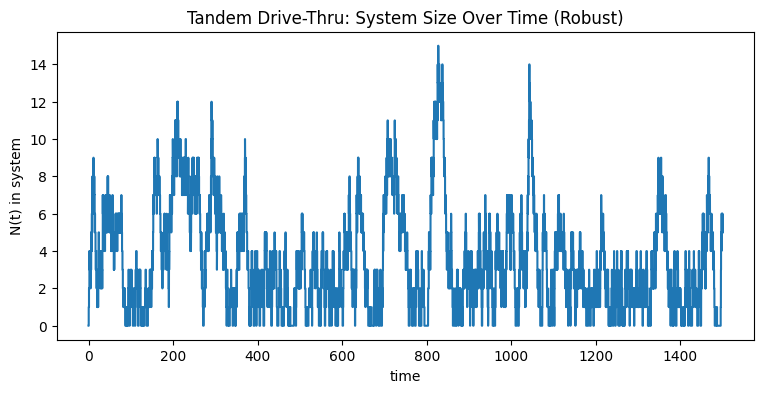

In [4]:

# Plot N(t)
if cfg.record_state_trajectory:
    plt.figure(figsize=(9,4))
    plt.step(sim.state_t, sim.state_n, where="post")
    plt.xlabel("time")
    plt.ylabel("N(t) in system")
    plt.title("Tandem Drive-Thru: System Size Over Time (Robust)")
    plt.show()
